<a href="https://colab.research.google.com/github/Arachmanda10/Cataract-Detection/blob/main/Cataract_Detect_commented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👁️ Deteksi Katarak dari Citra Mata dengan MobileNetV2

Notebook ini membangun model **klasifikasi biner (`cataract` vs `normal`)** dari foto mata menggunakan **transfer learning MobileNetV2** (bobot ImageNet) dengan TensorFlow/Keras. Dijalankan di Google Colab (GPU T4).

## Ringkasan
| Item | Keterangan |
|---|---|
| Dataset | [Kaggle – nandanp6/cataract-image-dataset](https://www.kaggle.com/datasets/nandanp6/cataract-image-dataset) |
| Jumlah data | Train 491 gambar (245 cataract, 246 normal) · Test 121 gambar (61 cataract, 60 normal) |
| Model | MobileNetV2 (ImageNet) + GlobalAveragePooling + Dropout(0,2) + Dense(2, softmax) |
| Input | 224 × 224 × 3, preprocessing bawaan MobileNetV2 (rentang [-1, 1]) |
| Hasil (test set) | Akurasi **91,74%** · Recall cataract **1,00** · Recall normal **0,83** |
| Ekspor | `.keras`, `.h5`, `.tflite` |

## Alur Notebook
1. Import modul
2. Persiapan lingkungan & dataset
3. Eksplorasi & validasi data
4. Pipeline data (split, augmentasi, preprocessing)
5. Membangun model
6. Kompilasi & training
7. Evaluasi
8. Menyimpan & ekspor model
9. Inferensi pada gambar baru

> ⚠️ **Disclaimer:** proyek ini dibuat untuk tujuan pembelajaran/portofolio dan **bukan alat diagnosis medis**. Hasil model tidak boleh menggantikan pemeriksaan oleh dokter mata.

## 1. Import Modul
Library dikelompokkan berdasarkan fungsinya: operasi dasar, visualisasi, metrik evaluasi, dan TensorFlow/Keras.

In [ ]:
# =========================
# CORE
# =========================
# os     : operasi file/folder (membaca isi direktori dataset)
# numpy  : operasi array numerik
# pandas : (belum dipakai di notebook ini, boleh dihapus)

import os
import numpy as np
import pandas as pd


# =========================
# VISUALIZATION
# =========================
# matplotlib & seaborn : menampilkan sampel gambar, kurva training, confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# MACHINE LEARNING
# =========================
# Metrik evaluasi dari scikit-learn

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


# =========================
# TENSORFLOW
# =========================
# MobileNetV2 : arsitektur pretrained yang ringan (cocok untuk mobile/TFLite)
# layers      : lapisan tambahan untuk "head" klasifikasi
# Model       : (belum dipakai langsung; model dibuat lewat tf.keras.Model)

import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras import layers

from tensorflow.keras.models import Model

## 2. Persiapan Lingkungan & Dataset
Dataset diunduh dari Kaggle lalu disalin ke Google Drive supaya tidak perlu diunduh ulang (±500 MB) setiap kali sesi Colab dimulai.

In [ ]:
# Mount Google Drive agar dataset dan model hasil training tersimpan permanen
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub

# Unduh dataset dari Kaggle (disimpan sementara di cache Colab)
# Catatan: path hasil unduhan mengandung nomor versi dataset, sehingga bisa berubah jika dataset diperbarui
path = kagglehub.dataset_download("nandanp6/cataract-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 503M/503M [00:26<00:00, 20.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nandanp6/cataract-image-dataset/versions/3


In [ ]:
import os
import shutil

# Folder asli hasil download Kaggle (berisi subfolder train/ dan test/)
source = os.path.join(path, "processed_images")

# Lokasi tujuan di Google Drive + nama baru
destination = "/content/drive/MyDrive/CataractDataset"

# Copy sekaligus rename folder
# dirs_exist_ok=True -> aman dijalankan ulang tanpa error jika folder tujuan sudah ada
shutil.copytree(
    source,
    destination,
    dirs_exist_ok=True
)

print("Dataset berhasil disimpan!")
print("Lokasi:", destination)

## 3. Eksplorasi & Validasi Data
Sebelum training, dicek: (1) jumlah gambar per kelas, (2) contoh visual, (3) variasi ukuran gambar, dan (4) integritas file.

### 3.1 Distribusi Kelas
Mengecek apakah data seimbang antar kelas. Hasilnya hampir seimbang (train 245 vs 246, test 61 vs 60), sehingga **akurasi** masih cukup representatif dan tidak perlu teknik penanganan imbalance.

In [ ]:
import os
dataset_path = "/content/drive/MyDrive/CataractDataset"
splits = ["train", "test"]

# Hitung jumlah gambar pada setiap kelas di setiap split
for split in splits:

    split_path = os.path.join(dataset_path, split)

    print(f"\n{'='*50}")
    print(f"{split.upper()} DATASET")
    print(f"{'='*50}")

    # Nama subfolder = nama kelas (cataract, normal)
    classes = sorted(os.listdir(split_path))

    total_images = 0

    for class_name in classes:

        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):

            # Hanya hitung file bergambar (jpg/jpeg/png)
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            jumlah = len(images)
            total_images += jumlah

            print(f"{class_name}: {jumlah}")

    print(f"\nTOTAL {split.upper()}: {total_images} gambar")


TRAIN DATASET
cataract: 245
normal: 246

TOTAL TRAIN: 491 gambar

TEST DATASET
cataract: 61
normal: 60

TOTAL TEST: 121 gambar


### 3.2 Contoh Gambar
Menampilkan 5 gambar acak per kelas untuk melihat sekilas perbedaan visual dan kualitas data.

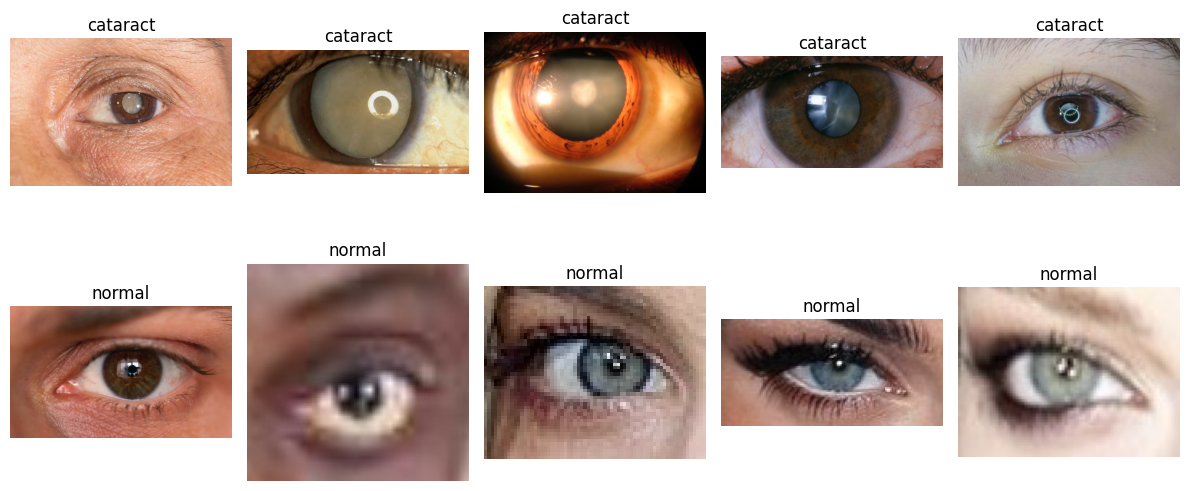

In [ ]:
import os
import random
import matplotlib.pyplot as plt
dataset_path = "/content/drive/MyDrive/CataractDataset"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

classes = ["cataract", "normal"]

plt.figure(figsize=(12, 6))

for i, class_name in enumerate(classes):

    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Ambil 5 gambar secara random
    selected_images = random.sample(images, min(5, len(images)))

    for j, image_name in enumerate(selected_images):

        image_path = os.path.join(class_path, image_name)

        image = plt.imread(image_path)

        # Baris 1 = cataract, baris 2 = normal (grid 2 x 5)
        position = i * 5 + j + 1

        plt.subplot(2, 5, position)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

### 3.3 Ukuran & Mode Gambar
Ukuran gambar **sangat bervariasi** (contoh: 117×123 hingga 2272×1476 piksel) sedangkan semua gambar berformat RGB. Karena itu semua gambar nanti harus di-*resize* ke ukuran seragam (224×224) sesuai input MobileNetV2.

In [ ]:
from PIL import Image

# Cek ukuran (lebar, tinggi) dan mode warna dari 10 gambar pertama tiap kelas
for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"\n{class_name.upper()}")

    for image_name in images[:10]:

        image_path = os.path.join(class_path, image_name)

        with Image.open(image_path) as img:
            print(
                f"{image_name} -> "
                f"{img.size} | "
                f"{img.mode}"
            )


CATARACT
image_161.png -> (400, 250) | RGB
image_205.png -> (600, 330) | RGB
image_203.png -> (597, 313) | RGB
image_167.png -> (1000, 1000) | RGB
image_157.png -> (1000, 1000) | RGB
image_194.png -> (2250, 1500) | RGB
image_142.png -> (860, 520) | RGB
image_204.png -> (850, 350) | RGB
image_189.png -> (999, 650) | RGB
image_17.png -> (500, 309) | RGB

NORMAL
image_158.png -> (579, 449) | RGB
image_191.png -> (2098, 1392) | RGB
image_176.png -> (2272, 1476) | RGB
image_185.png -> (250, 250) | RGB
image_11.png -> (235, 129) | RGB
image_130.png -> (117, 123) | RGB
image_217.png -> (321, 229) | RGB
image_155.png -> (227, 185) | RGB
image_208.png -> (1247, 933) | RGB
image_135.png -> (311, 236) | RGB


### 3.4 Pengecekan File Rusak
Memastikan tidak ada gambar korup yang dapat membuat proses training berhenti di tengah jalan. Hasil: **tidak ada file bermasalah**.

In [ ]:
from PIL import Image

for split in ["train", "test"]:

    split_path = os.path.join(dataset_path, split)

    print(f"\nChecking {split}...")

    for class_name in ["cataract", "normal"]:

        class_path = os.path.join(split_path, class_name)

        for image_name in os.listdir(class_path):

            # Lewati file non-gambar
            if not image_name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                continue

            image_path = os.path.join(
                class_path,
                image_name
            )

            # verify() akan melempar error jika file gambar rusak
            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception as e:
                print(
                    f"❌ File bermasalah: "
                    f"{image_path}"
                )

print("\nPengecekan selesai.")


Checking train...

Checking test...

Pengecekan selesai.


## 4. Pipeline Data
Tahap ini menyiapkan data untuk training:
- **Split:** 80% train / 20% validation dari folder `train` (seed tetap agar reproducible), folder `test` dipakai murni untuk evaluasi akhir.
- **Resize:** semua gambar diubah menjadi 224×224.
- **Augmentasi:** hanya untuk data train.
- **Preprocessing:** `mobilenet_v2.preprocess_input` (skala piksel ke [-1, 1]), diterapkan konsisten di train, validation, test, dan saat inferensi.

### 4.1 Memuat Dataset dari Folder

In [ ]:
# Hyperparameter data
IMG_SIZE = (224, 224)   # ukuran input MobileNetV2
BATCH_SIZE = 32
SEED = 42               # seed yang sama di train & validation agar split tidak saling tumpang tindih

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

# Urutan kelas mengikuti urutan alfabet folder: cataract = 0, normal = 1
class_names = ["cataract", "normal"]

# Data training (80% dari folder train)
# label_mode="categorical" -> label one-hot, cocok dengan Dense(2, softmax) + categorical_crossentropy
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Data validation (20% sisanya dari folder train)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Data test (folder terpisah)
# shuffle=False agar urutan prediksi sama dengan urutan label saat membuat confusion matrix
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# ⚠️ Catatan: baris ini mencetak objek dataset, bukan nama kelas.
# Untuk menampilkan nama kelas, gunakan: print("Class names:", train_ds_raw.class_names)
print("Class names:", train_ds_raw)

Found 491 files belonging to 2 classes.
Using 393 files for training.
Found 491 files belonging to 2 classes.
Using 98 files for validation.
Found 121 files belonging to 2 classes.
Class names: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>


### 4.2 Augmentasi Data
Augmentasi ringan (flip horizontal, rotasi ±5%, zoom ±10%) untuk memperbanyak variasi data train dan mengurangi overfitting, mengingat datanya kecil (hanya 393 gambar untuk training).

In [ ]:
# Layer augmentasi (hanya aktif saat training=True)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # cermin kiri-kanan
    tf.keras.layers.RandomRotation(0.05),       # rotasi acak kecil
    tf.keras.layers.RandomZoom(0.1),            # zoom acak kecil
])

### 4.3 Preprocessing & Optimasi Pipeline
- Train: augmentasi → `preprocess_input`
- Validation/Test: hanya `preprocess_input` (tanpa augmentasi agar evaluasi adil)
- `prefetch(AUTOTUNE)` menyiapkan batch berikutnya sambil GPU memproses batch saat ini sehingga training lebih cepat.

In [ ]:
def preprocess_train(image, label):

    # Augmentasi dulu (pada piksel 0-255), baru normalisasi
    image = data_augmentation(image, training=True)

    # Skala piksel dari [0, 255] ke [-1, 1] sesuai kebutuhan MobileNetV2
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label


def preprocess_val_test(image, label):

    # Tanpa augmentasi, hanya normalisasi
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label


# Terapkan fungsi preprocessing ke tiap dataset (paralel)
train_ds = train_ds_raw.map(
    preprocess_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds_raw.map(
    preprocess_val_test,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds_raw.map(
    preprocess_val_test,
    num_parallel_calls=tf.data.AUTOTUNE
)

AUTOTUNE = tf.data.AUTOTUNE

# Prefetch: siapkan batch berikutnya di background
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### 4.4 Visualisasi Hasil Pipeline
Memeriksa bahwa gambar hasil augmentasi/preprocessing masih wajar dan labelnya benar.

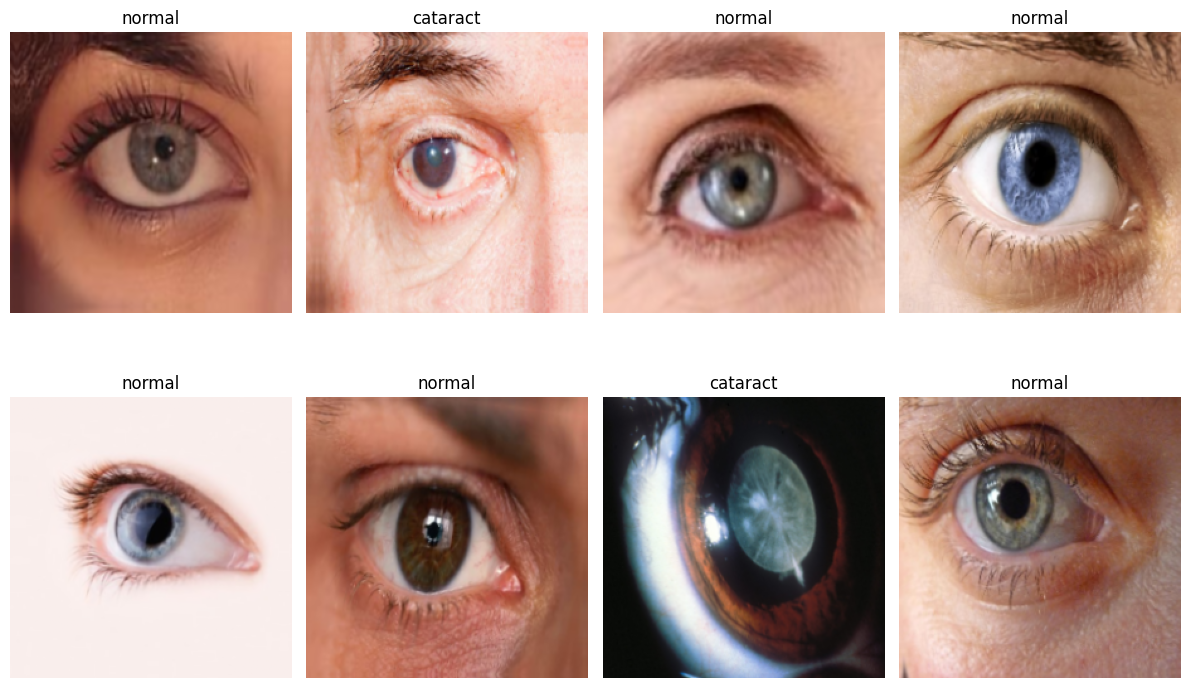

In [ ]:
class_names = ["cataract", "normal"]

plt.figure(figsize=(12, 8))

# Ambil 1 batch dari data train yang sudah diaugmentasi
for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)

        # [-1, 1] → [0, 1] untuk visualisasi
        image = (images[i] + 1) / 2

        plt.imshow(image)

        # One-hot label → index kelas
        label = tf.argmax(labels[i]).numpy()

        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Membangun Model
Arsitektur: **MobileNetV2 (pretrained ImageNet, tanpa top layer)** sebagai ekstraktor fitur, lalu ditambah *head* klasifikasi:

`MobileNetV2 → GlobalAveragePooling2D → Dropout(0,2) → Dense(2, softmax)`

MobileNetV2 dipilih karena ringan (±2,3 juta parameter) sehingga cocok untuk dataset kecil dan mudah diekspor ke TFLite.

### 5.1 Base Model

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# include_top=False -> buang classifier ImageNet (1000 kelas), kita ganti dengan head sendiri
# weights="imagenet" -> gunakan bobot hasil pretraining (transfer learning)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# ⚠️ Catatan: base_model tidak dibekukan (base_model.trainable = False tidak dipanggil),
# sehingga seluruh ±2,2 juta parameter ikut dilatih (lihat "Trainable params" pada model.summary()).
# Jika tujuannya feature extraction, tambahkan: base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 5.2 Head Klasifikasi

In [ ]:
from tensorflow.keras import layers

# Meringkas feature map 7x7x1280 menjadi vektor 1280 (rata-rata per channel)
global_average_layer = layers.GlobalAveragePooling2D()

# Dropout 20% untuk mengurangi overfitting
dropout_layer = layers.Dropout(0.2)

# Output 2 neuron (cataract, normal) dengan softmax -> probabilitas per kelas
output_layer = layers.Dense(
    2,
    activation="softmax"
)

### 5.3 Menyusun Model Utuh (Functional API)

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# training=False -> layer BatchNormalization di base model memakai statistik pretrained (mode inferensi)
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = dropout_layer(x)
outputs = output_layer(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
# Ringkasan arsitektur dan jumlah parameter
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,226,434 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)

**Catatan:** dari ±2,26 juta parameter total, sekitar 2,23 juta berstatus *trainable*, artinya seluruh MobileNetV2 ikut di-*fine-tune*, bukan hanya head klasifikasi (lihat catatan pada bagian 5.1).

## 6. Kompilasi & Training
- **Optimizer:** Adam, learning rate 0,0001 (kecil, karena memakai bobot pretrained)
- **Loss:** categorical crossentropy (sesuai label one-hot)
- **EarlyStopping:** berhenti jika `val_loss` tidak membaik selama 5 epoch, lalu mengembalikan bobot terbaik.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Hentikan training otomatis saat val_loss stagnan, dan pulihkan bobot terbaik
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Training maksimal 30 epoch (biasanya berhenti lebih awal karena EarlyStopping)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8092 - loss: 0.3764 - val_accuracy: 0.8265 - val_loss: 0.4588
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 967ms/step - accuracy: 0.9593 - loss: 0.1045 - val_accuracy: 0.7959 - val_loss: 0.5301
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9847 - loss: 0.0628 - val_accuracy: 0.8673 - val_loss: 0.4433
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 997ms/step - accuracy: 0.9949 - loss: 0.0338 - val_accuracy: 0.8673 - val_loss: 0.4001
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9975 - loss: 0.0195 - val_accuracy: 0.8776 - val_loss: 0.3860
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 957ms/step - accuracy: 0.9949 - loss: 0.0209 - val_accuracy: 0.8776 - val_loss: 0.3573
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9975 - loss: 0.0125 - val_accuracy: 0.9082 - val_loss: 0.3346
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.9082 - 

**Interpretasi training:** akurasi train mencapai ±100% sejak epoch 8, sedangkan akurasi validasi bertahan di kisaran 83–91%. `val_loss` terendah dicapai pada epoch 8 (0,3327) lalu naik, tanda **overfitting** dimulai. EarlyStopping menghentikan training di epoch 13 dan memulihkan bobot terbaik dari epoch 8.

Perlu diingat set validasi hanya berisi 98 gambar, jadi angka validasi cukup berfluktuasi antar epoch.

## 7. Evaluasi Model
### 7.1 Kurva Training
Membandingkan akurasi dan loss antara data train dan validation per epoch untuk melihat overfitting.

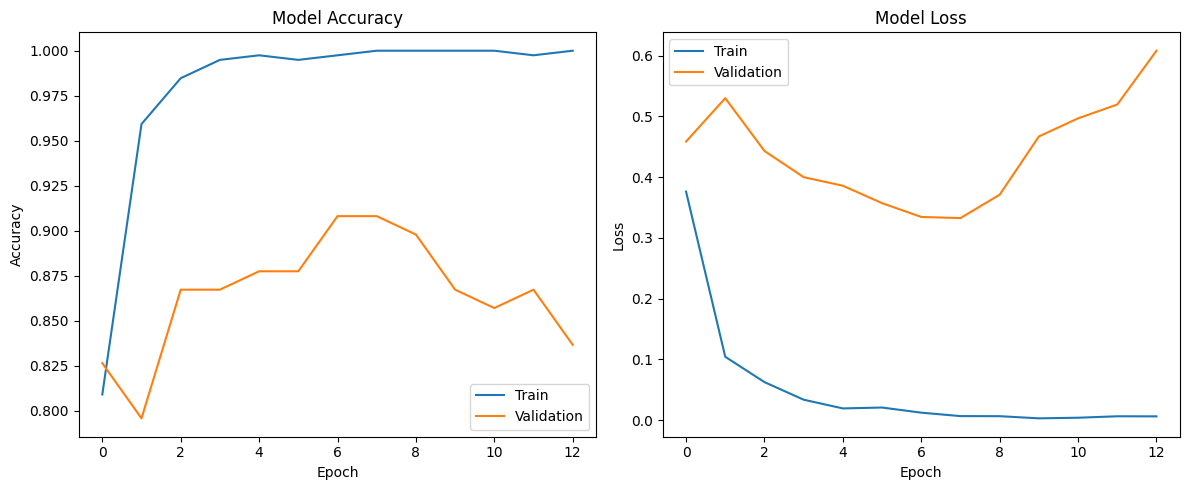

In [ ]:
plt.figure(figsize=(12, 5))

# Grafik akurasi
plt.subplot(1, 2, 1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Grafik loss
plt.subplot(1, 2, 2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### 7.2 Evaluasi pada Test Set
Data test belum pernah dilihat model selama training maupun pemilihan epoch, sehingga merupakan ukuran performa yang paling jujur.

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9174 - loss: 0.2062
Test Loss     : 0.2062
Test Accuracy : 0.9174


### 7.3 Confusion Matrix & Classification Report
Akurasi saja tidak cukup untuk kasus medis karena jenis kesalahan sama pentingnya. Karena itu dilihat juga confusion matrix, precision, dan recall per kelas.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

# Kumpulkan label asli & prediksi untuk seluruh test set
# (aman karena test_ds dibuat dengan shuffle=False)
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Baris = label asli, kolom = prediksi
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[61  0]
 [10 50]]


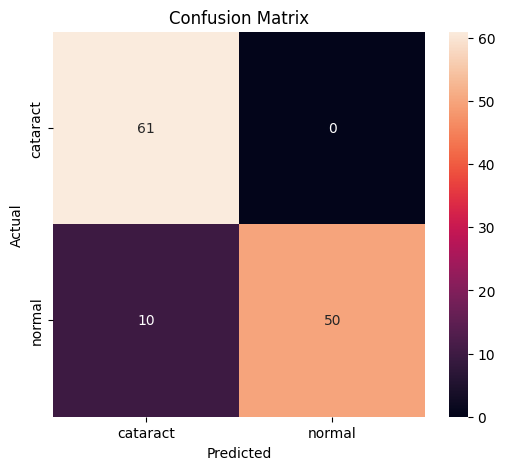

In [ ]:
# Visualisasi confusion matrix dalam bentuk heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Precision, recall, dan F1-score per kelas
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    cataract       0.86      1.00      0.92        61
      normal       1.00      0.83      0.91        60

    accuracy                           0.92       121
   macro avg       0.93      0.92      0.92       121
weighted avg       0.93      0.92      0.92       121



**Interpretasi hasil:**
- Akurasi test **91,74%** (111 dari 121 gambar benar).
- **Katarak: recall 1,00**, semua 61 gambar katarak terdeteksi (tidak ada *false negative*).
- **Normal: recall 0,83**, 10 mata normal salah diprediksi sebagai katarak (*false positive*), sehingga precision katarak turun menjadi 0,86.
- Pola kesalahan ini relatif lebih aman untuk konteks **skrining**, karena lebih baik mata normal diminta periksa ulang daripada katarak terlewat.
- Test set hanya 121 gambar, jadi 1 gambar ≈ 0,83 poin persentase dan estimasi performa masih memiliki ketidakpastian yang cukup lebar.

## 8. Menyimpan & Ekspor Model
Model disimpan dalam tiga format:
- `.keras` : format native Keras (direkomendasikan)
- `.h5` : format legacy HDF5 (untuk kompatibilitas dengan kode lama)
- `.tflite` : untuk deployment di perangkat mobile/edge

> ⚠️ Preprocessing (`preprocess_input`) **tidak ikut tersimpan di dalam model**. Saat model dipakai di aplikasi lain, gambar harus di-resize ke 224×224 dan dinormalisasi ke rentang [-1, 1] terlebih dahulu.

In [ ]:
# Format native Keras (direkomendasikan)
model.save(
    "/content/drive/MyDrive/CataractDataset/cataract_model.keras"
)

In [ ]:
# Format HDF5 (legacy). Keras menampilkan warning karena format ini sudah tidak direkomendasikan
model.save(
    "/content/drive/MyDrive/CataractDataset/cataract_model.h5"
)

In [ ]:
# Konversi ke TensorFlow Lite (tanpa kuantisasi, jadi masih float32)
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

# Simpan hasil konversi sebagai file biner
with open(
    "/content/drive/MyDrive/CataractDataset/cataract_model.tflite",
    "wb"
) as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmplzh85fgs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_158')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137403187296784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187297552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187297360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187297744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187296592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187297936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187298128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187296400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187297168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137403187296976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1374031875

## 9. Inferensi pada Gambar Baru
Mencoba model pada satu gambar yang diunggah manual, mulai dari langkah-langkah terpisah lalu dirangkum menjadi fungsi `predict_image()` agar bisa dipakai ulang.

In [ ]:
from google.colab import files

# Unggah gambar mata dari komputer lokal
uploaded = files.upload()

Saving image_292.png to image_292.png


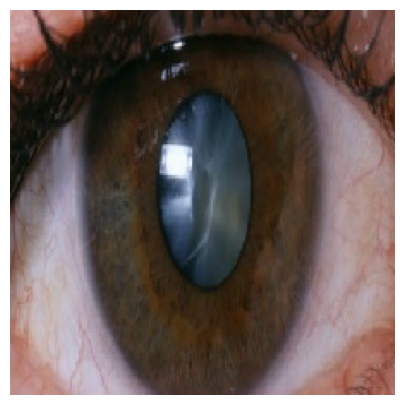

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt

# Ambil nama file yang baru diunggah
filename = next(iter(uploaded))

# Muat gambar dan ubah ke ukuran input model
img = load_img(
    filename,
    target_size=(224, 224)
)

img_array = img_to_array(img)

# Tampilkan gambar yang akan diprediksi
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
# Sel pengecekan fungsi preprocessing (bersifat eksploratif, boleh dihapus)
tf.keras.applications.mobilenet_v2.preprocess_input

<function keras.src.applications.mobilenet_v2.preprocess_input(x, data_format=None)>

In [ ]:
import numpy as np
import tensorflow as tf

# Tambah dimensi batch: (224, 224, 3) -> (1, 224, 224, 3)
img_array = np.expand_dims(img_array, axis=0)

# Normalisasi yang sama persis seperti saat training
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(
    img_array
)

In [ ]:
# ⚠️ Catatan: variabel `prediction` belum didefinisikan di notebook ini (sel yang menjalankan
# model.predict tidak ada), sehingga sel ini akan menghasilkan NameError jika dijalankan berurutan.
# Perbaikan: tambahkan `prediction = model.predict(img_array)` sebelum sel ini,
# atau hapus sel ini karena sudah digantikan oleh fungsi predict_image() di bawah.
predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

print("Prediction :", class_names[predicted_class])
print("Confidence :", f"{confidence:.2%}")

Prediction : cataract
Confidence : 99.97%


### Fungsi Prediksi Reusable
Menggabungkan seluruh langkah inferensi (load → resize → preprocess → predict) dalam satu fungsi.

In [ ]:
def predict_image(filename, model, class_names):
    # 1. Muat & resize gambar
    img = load_img(
        filename,
        target_size=(224, 224)
    )

    # 2. Ubah ke array dan tambah dimensi batch
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Normalisasi sesuai MobileNetV2
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        img_array
    )

    # 4. Prediksi (output: probabilitas tiap kelas)
    prediction = model.predict(img_array, verbose=0)[0]

    # 5. Ambil kelas dengan probabilitas tertinggi
    predicted_class = np.argmax(prediction)
    confidence = prediction[predicted_class]

    print(f"Prediction : {class_names[predicted_class]}")
    print(f"Confidence : {confidence:.2%}")

    return predicted_class, confidence

In [ ]:
# Contoh pemakaian fungsi pada gambar yang diunggah
predict_image(
    filename,
    model,
    class_names
)

Prediction : cataract
Confidence : 99.97%


(np.int64(0), np.float32(0.99970406))

> **Catatan:** nilai *confidence* dari softmax bukan probabilitas klinis yang terkalibrasi. Nilai tinggi (misalnya 99,97%) tidak menjamin prediksi benar, terutama pada gambar yang berbeda dari data training.